<a href="https://colab.research.google.com/github/MaryAshnaKR/AI/blob/main/crop_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
print(os.path.getsize("/content/archive (18).zip"))

11534336


In [2]:
!file "/content/archive (18).zip"

/content/archive (18).zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [3]:
!unzip -l "/content/archive (18).zip" | head

  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/archive (18).zip or
        /content/archive (18).zip.zip, and cannot find /content/archive (18).zip.ZIP, period.
Archive:  /content/archive (18).zip


In [4]:
!unzip "/content/archive (18).zip" -d /content/crop_disease

Archive:  /content/archive (18).zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/archive (18).zip or
        /content/archive (18).zip.zip, and cannot find /content/archive (18).zip.ZIP, period.


In [5]:
!rm "/content/archive (18).zip"
!kaggle datasets download -d nirmalsankalana/crop-pest-and-disease-detection -p /content
!unzip "/content/crop-pest-and-disease-detection.zip" -d /content/crop_disease

Streaming output truncated to the last 5000 lines.
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1302_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1303_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1304_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1305_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1306_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1307_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1308_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1309_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight130_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1310_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1311_.jpg  
  inflating: /content/crop_disease/Tomato leaf blight/leaf blight1312_.jpg  
  inflating: /content/crop

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create generators with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   # 20% for validation
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    "/content/crop_disease",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    "/content/crop_disease",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 20186 images belonging to 22 classes.
Found 5034 images belonging to 22 classes.


In [7]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Compile
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
train_gen = train_datagen.flow_from_directory(
    "/content/crop_disease",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    "/content/crop_disease",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 20186 images belonging to 22 classes.
Found 5034 images belonging to 22 classes.


In [9]:
import tensorflow as tf
tf.config.experimental.enable_op_determinism()  # optional

In [10]:
import os
from PIL import Image

bad_files = []
for root, dirs, files in os.walk("/content/crop_disease"):
    for file in files:
        try:
            Image.open(os.path.join(root, file)).verify()
        except:
            bad_files.append(os.path.join(root, file))

print("Corrupted files:", bad_files)

Corrupted files: ['/content/crop_disease/Maize streak virus/streak virus998_.jpg', '/content/crop_disease/Maize streak virus/streak virus774_.jpg', '/content/crop_disease/Maize streak virus/streak virus701_.jpg', '/content/crop_disease/Maize streak virus/streak virus486_.jpg', '/content/crop_disease/Maize streak virus/streak virus119_.jpg', '/content/crop_disease/Maize streak virus/streak virus627_.jpg', '/content/crop_disease/Maize streak virus/streak virus422_.jpg', '/content/crop_disease/Tomato leaf curl/leaf curl354_.jpg', '/content/crop_disease/Tomato leaf curl/leaf curl43_.jpg', '/content/crop_disease/Tomato leaf curl/leaf curl186_.jpg', '/content/crop_disease/Tomato leaf curl/leaf curl271_.jpg', '/content/crop_disease/Maize healthy/healthy18_.jpg', '/content/crop_disease/Maize healthy/healthy88_.jpg', '/content/crop_disease/Maize leaf beetle/leaf beetle691_.jpg', '/content/crop_disease/Maize leaf beetle/leaf beetle798_.jpg', '/content/crop_disease/Maize leaf beetle/leaf beetle20

In [11]:
for f in bad_files:
    os.remove(f)

print("Deleted", len(bad_files), "corrupted files")


Deleted 50 corrupted files


In [12]:
train_gen = train_datagen.flow_from_directory(
    "/content/crop_disease",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    "/content/crop_disease",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 20147 images belonging to 22 classes.
Found 5023 images belonging to 22 classes.


In [13]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [14]:
import os
from PIL import Image

for root, dirs, files in os.walk("/content/crop_disease"):
    for file in files:
        try:
            path = os.path.join(root, file)
            img = Image.open(path).convert("RGB")
            img.save(path)  # overwrite with safe RGB version
        except:
            os.remove(path)  # delete if totally unreadable

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/crop_disease_model.h5",   # file to save
    save_best_only=True,                # only keep best model
    monitor="val_accuracy",             # track validation accuracy
    mode="max"                          # maximize accuracy
)

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=len(train_gen),
    validation_steps=len(val_gen),
    callbacks=[checkpoint]
)

Epoch 1/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.1042 - loss: 2.9705

630/630 ━━━━━━━━━━━━━━━━━━━━ 400s 596ms/step - accuracy: 0.1062 - loss: 2.9589 - val_accuracy: 0.1091 - val_loss: 2.9403
Epoch 2/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 344s 547ms/step - accuracy: 0.1072 - loss: 2.9486 - val_accuracy: 0.1039 - val_loss: 2.9430
Epoch 3/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 365s 580ms/step - accuracy: 0.1087 - loss: 2.9438 - val_accuracy: 0.1039 - val_loss: 2.9423
Epoch 4/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 350s 555ms/step - accuracy: 0.1034 - loss: 2.9434 - val_accuracy: 0.1091 - val_loss: 2.9392
Epoch 5/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 326s 517ms/step - accuracy: 0.1096 - loss: 2.9413 - val_accuracy: 0.1091 - val_loss: 2.9361
Epoch 6/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 321s 509ms/step - accuracy: 0.1061 - loss: 2.9401 - val_accuracy: 0.1091 - val_loss: 2.9370
Epoch 7/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 317s 503ms/step - accuracy: 0.1077 - loss: 2.9393 - val_accuracy: 0.1091 - val_loss: 2.9382
Epoch 8/10
630/630 ━━━━━━━━━━━━━━━━━━━━ 337s 536ms/step - accuracy: 0.1048 - loss: 2.94

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    "crop_disease",        # path to your dataset folder
    target_size=(224, 224),# resize images
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    "crop_disease",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)


Found 20147 images belonging to 22 classes.
Found 5023 images belonging to 22 classes.


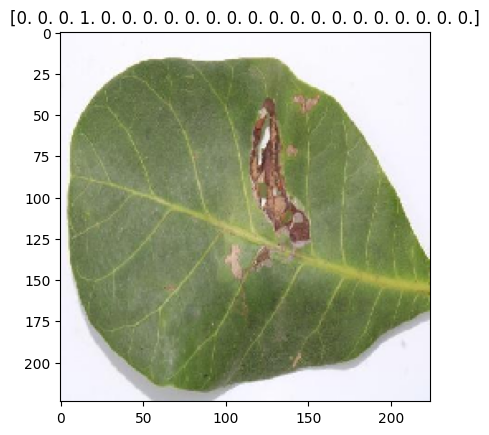

In [19]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)
plt.imshow(images[0])
plt.title(labels[0])
plt.show()


In [20]:
train_generator.class_indices


{'Cashew anthracnose': 0,
 'Cashew gumosis': 1,
 'Cashew healthy': 2,
 'Cashew leaf miner': 3,
 'Cashew red rust': 4,
 'Cassava bacterial blight': 5,
 'Cassava brown spot': 6,
 'Cassava green mite': 7,
 'Cassava healthy': 8,
 'Cassava mosaic': 9,
 'Maize fall armyworm': 10,
 'Maize grasshoper': 11,
 'Maize healthy': 12,
 'Maize leaf beetle': 13,
 'Maize leaf blight': 14,
 'Maize leaf spot': 15,
 'Maize streak virus': 16,
 'Tomato healthy': 17,
 'Tomato leaf blight': 18,
 'Tomato leaf curl': 19,
 'Tomato septoria leaf spot': 20,
 'Tomato verticulium wilt': 21}

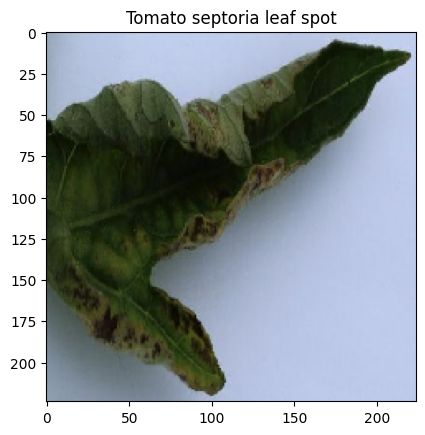

In [21]:
images, labels = next(train_generator)
plt.imshow(images[0])
class_index = labels[0].argmax()
class_name = list(train_generator.class_indices.keys())[class_index]
plt.title(class_name)
plt.show()


In [22]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

# Load base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(22, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base layers initially
for layer in base_model.layers:
    layer.trainable = False

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [23]:
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=15)


Epoch 1/15
630/630 ━━━━━━━━━━━━━━━━━━━━ 110s 153ms/step - accuracy: 0.1004 - loss: 2.9965 - val_accuracy: 0.1091 - val_loss: 2.9595
Epoch 2/15
630/630 ━━━━━━━━━━━━━━━━━━━━ 93s 147ms/step - accuracy: 0.0983 - loss: 2.9901 - val_accuracy: 0.1039 - val_loss: 2.9594
Epoch 3/15
630/630 ━━━━━━━━━━━━━━━━━━━━ 92s 147ms/step - accuracy: 0.1007 - loss: 2.9914 - val_accuracy: 0.1039 - val_loss: 2.9732
Epoch 4/15
630/630 ━━━━━━━━━━━━━━━━━━━━ 94s 150ms/step - accuracy: 0.0989 - loss: 2.9867 - val_accuracy: 0.1091 - val_loss: 2.9463
Epoch 5/15
630/630 ━━━━━━━━━━━━━━━━━━━━ 92s 146ms/step - accuracy: 0.1006 - loss: 2.9857 - val_accuracy: 0.1039 - val_loss: 2.9598
Epoch 6/15
630/630 ━━━━━━━━━━━━━━━━━━━━ 93s 147ms/step - accuracy: 0.0991 - loss: 2.9870 - val_accuracy: 0.1091 - val_loss: 2.9663
Epoch 7/15
630/630 ━━━━━━━━━━━━━━━━━━━━ 93s 147ms/step - accuracy: 0.1008 - loss: 2.9902 - val_accuracy: 0.1091 - val_loss: 2.9526
Epoch 8/15
630/630 ━━━━━━━━━━━━━━━━━━━━ 93s 147ms/step - accuracy: 0.1017 - loss: 

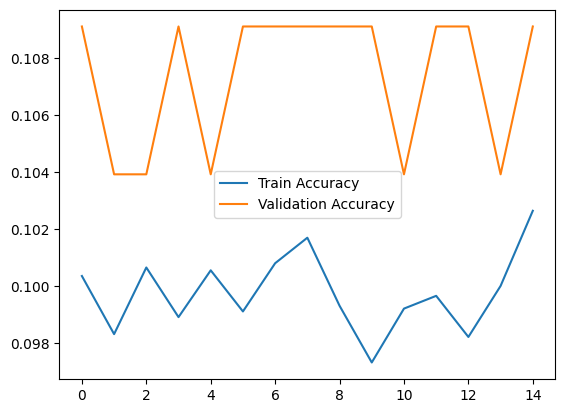

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


In [26]:
model.save("crop_disease_model.h5")


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels from validation generator
y_true = val_generator.classes

# Predict on validation set
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=list(train_generator.class_indices.keys())))


157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step
                           precision    recall  f1-score   support

       Cashew anthracnose       0.00      0.00      0.00       345
           Cashew gumosis       0.00      0.00      0.00        78
           Cashew healthy       0.00      0.00      0.00       273
        Cashew leaf miner       0.00      0.00      0.00       275
          Cashew red rust       0.00      0.00      0.00       336
 Cassava bacterial blight       0.00      0.00      0.00       522
       Cassava brown spot       0.00      0.00      0.00       296
       Cassava green mite       0.00      0.00      0.00       203
          Cassava healthy       0.00      0.00      0.00       238
           Cassava mosaic       0.00      0.00      0.00       241
      Maize fall armyworm       0.00      0.00      0.00        57
         Maize grasshoper       0.00      0.00      0.00       134
            Maize healthy       0.00      0.00      0.00        41
        Maize lea

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


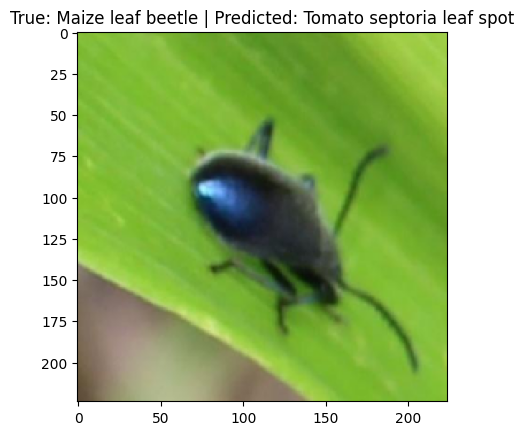

In [29]:
import matplotlib.pyplot as plt
import random

# Pick a random sample from validation set
images, labels = next(val_generator)
idx = random.randint(0, len(images)-1)

plt.imshow(images[idx])
true_class = list(train_generator.class_indices.keys())[labels[idx].argmax()]
pred_class = list(train_generator.class_indices.keys())[y_pred_classes[idx]]
plt.title(f"True: {true_class} | Predicted: {pred_class}")
plt.show()


In [30]:
model.save("crop_disease_model.h5")
